In [2]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers

os.environ["CUDA_VISIBLE_DEVICES"]= "0"

## Load EffNet : 15AB

In [3]:
# path_modelJson = "/media/tohn/HDD/Model_unlearn/Models_USAI/R1/models/modelEffNetB5_EffNet-base_transfer-R1.json"
# path_modelweights = "/media/tohn/HDD/Model_unlearn/Models_USAI/R1/models/modelEffNetB5_EffNet-base_transfer-R1.weights.h5"

# ##load json and create model --------------------
# json_file = open(path_modelJson, 'r')
# loaded_model_json = json_file.read()
# json_file.close()
# model = model_from_json(loaded_model_json)
# #load weights into new model  -------------------

# model.load_weights(path_modelweights)
# print("Loaded model from disk")
# model.compile(loss='categorical_crossentropy',
#               optimizer=optimizers.RMSprop(learning_rate=2e-5),
#               metrics=['accuracy'])
# height = width = model.input_shape[1]
# print("print Input shape: ", height, width)
# model.summary()

In [4]:
model_dir = '/media/tohn/HDD/Model_unlearn/Models_USAI/R2/models/modelEffNetB5_EffNet-base_Block5a_se_excite-R2.h5'
print(f"Load Model: {model_dir}")
model = load_model(model_dir)
height = width = model.input_shape[1]
print(height, width)

model.summary()

Load Model: /media/tohn/HDD/Model_unlearn/Models_USAI/R2/models/modelEffNetB5_EffNet-base_Block5a_se_excite-R2.h5
456 456
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 456, 456, 3) 0                                            
__________________________________________________________________________________________________
rescaling (Rescaling)           (None, 456, 456, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
normalization (Normalization)   (None, 456, 456, 3)  7           rescaling[0][0]                  
__________________________________________________________________________________________________
stem_conv_pad (ZeroPadding2D)   (None, 457, 457, 3)  0           normal

block6h_se_reshape (Reshape)    (None, 1, 1, 1824)   0           block6h_se_squeeze[0][0]         
__________________________________________________________________________________________________
block6h_se_reduce (Conv2D)      (None, 1, 1, 76)     138700      block6h_se_reshape[0][0]         
__________________________________________________________________________________________________
block6h_se_expand (Conv2D)      (None, 1, 1, 1824)   140448      block6h_se_reduce[0][0]          
__________________________________________________________________________________________________
block6h_se_excite (Multiply)    (None, 15, 15, 1824) 0           block6h_activation[0][0]         
                                                                 block6h_se_expand[0][0]          
__________________________________________________________________________________________________
block6h_project_conv (Conv2D)   (None, 15, 15, 304)  554496      block6h_se_excite[0][0]          
__________

In [5]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv('/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv('/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [6]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [7]:
print(len(set(dataframe['Sub_class_New'])))
print(set(dataframe['Sub_class_New']))

15
{'AB11', 'AB03', 'AB10', 'AB09', 'AB12', 'AB081', 'AB05', 'AB07', 'AB06', 'AB01', 'AB082', 'AB02', 'AB083', 'AB04', 'Normal'}


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [9]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])
    print("[INFO]: predict image: ", i+1)

dataframe['category'] = pred_list
dataframe['Prob'] = prob_list

[INFO]: predict image:  1
[INFO]: predict image:  2
[INFO]: predict image:  3
[INFO]: predict image:  4
[INFO]: predict image:  5
[INFO]: predict image:  6
[INFO]: predict image:  7
[INFO]: predict image:  8
[INFO]: predict image:  9
[INFO]: predict image:  10
[INFO]: predict image:  11
[INFO]: predict image:  12
[INFO]: predict image:  13
[INFO]: predict image:  14
[INFO]: predict image:  15
[INFO]: predict image:  16
[INFO]: predict image:  17
[INFO]: predict image:  18
[INFO]: predict image:  19
[INFO]: predict image:  20
[INFO]: predict image:  21
[INFO]: predict image:  22
[INFO]: predict image:  23
[INFO]: predict image:  24
[INFO]: predict image:  25
[INFO]: predict image:  26
[INFO]: predict image:  27
[INFO]: predict image:  28
[INFO]: predict image:  29
[INFO]: predict image:  30
[INFO]: predict image:  31
[INFO]: predict image:  32
[INFO]: predict image:  33
[INFO]: predict image:  34
[INFO]: predict image:  35
[INFO]: predict image:  36
[INFO]: predict image:  37
[INFO]: pr

[INFO]: predict image:  298
[INFO]: predict image:  299
[INFO]: predict image:  300
[INFO]: predict image:  301
[INFO]: predict image:  302
[INFO]: predict image:  303
[INFO]: predict image:  304
[INFO]: predict image:  305
[INFO]: predict image:  306
[INFO]: predict image:  307
[INFO]: predict image:  308
[INFO]: predict image:  309
[INFO]: predict image:  310
[INFO]: predict image:  311
[INFO]: predict image:  312
[INFO]: predict image:  313
[INFO]: predict image:  314
[INFO]: predict image:  315
[INFO]: predict image:  316
[INFO]: predict image:  317
[INFO]: predict image:  318
[INFO]: predict image:  319
[INFO]: predict image:  320
[INFO]: predict image:  321
[INFO]: predict image:  322
[INFO]: predict image:  323
[INFO]: predict image:  324
[INFO]: predict image:  325
[INFO]: predict image:  326
[INFO]: predict image:  327
[INFO]: predict image:  328
[INFO]: predict image:  329
[INFO]: predict image:  330
[INFO]: predict image:  331
[INFO]: predict image:  332
[INFO]: predict imag

[INFO]: predict image:  592
[INFO]: predict image:  593
[INFO]: predict image:  594
[INFO]: predict image:  595
[INFO]: predict image:  596
[INFO]: predict image:  597
[INFO]: predict image:  598
[INFO]: predict image:  599
[INFO]: predict image:  600
[INFO]: predict image:  601
[INFO]: predict image:  602
[INFO]: predict image:  603
[INFO]: predict image:  604
[INFO]: predict image:  605
[INFO]: predict image:  606
[INFO]: predict image:  607
[INFO]: predict image:  608
[INFO]: predict image:  609
[INFO]: predict image:  610
[INFO]: predict image:  611
[INFO]: predict image:  612
[INFO]: predict image:  613
[INFO]: predict image:  614
[INFO]: predict image:  615
[INFO]: predict image:  616
[INFO]: predict image:  617
[INFO]: predict image:  618
[INFO]: predict image:  619
[INFO]: predict image:  620
[INFO]: predict image:  621
[INFO]: predict image:  622
[INFO]: predict image:  623
[INFO]: predict image:  624
[INFO]: predict image:  625
[INFO]: predict image:  626
[INFO]: predict imag

[INFO]: predict image:  886
[INFO]: predict image:  887
[INFO]: predict image:  888
[INFO]: predict image:  889
[INFO]: predict image:  890
[INFO]: predict image:  891
[INFO]: predict image:  892
[INFO]: predict image:  893
[INFO]: predict image:  894
[INFO]: predict image:  895
[INFO]: predict image:  896
[INFO]: predict image:  897
[INFO]: predict image:  898
[INFO]: predict image:  899
[INFO]: predict image:  900
[INFO]: predict image:  901
[INFO]: predict image:  902
[INFO]: predict image:  903
[INFO]: predict image:  904
[INFO]: predict image:  905
[INFO]: predict image:  906
[INFO]: predict image:  907
[INFO]: predict image:  908
[INFO]: predict image:  909
[INFO]: predict image:  910
[INFO]: predict image:  911
[INFO]: predict image:  912
[INFO]: predict image:  913
[INFO]: predict image:  914
[INFO]: predict image:  915
[INFO]: predict image:  916
[INFO]: predict image:  917
[INFO]: predict image:  918
[INFO]: predict image:  919
[INFO]: predict image:  920
[INFO]: predict imag

[INFO]: predict image:  1173
[INFO]: predict image:  1174
[INFO]: predict image:  1175
[INFO]: predict image:  1176
[INFO]: predict image:  1177
[INFO]: predict image:  1178
[INFO]: predict image:  1179
[INFO]: predict image:  1180
[INFO]: predict image:  1181
[INFO]: predict image:  1182
[INFO]: predict image:  1183
[INFO]: predict image:  1184
[INFO]: predict image:  1185
[INFO]: predict image:  1186
[INFO]: predict image:  1187
[INFO]: predict image:  1188
[INFO]: predict image:  1189
[INFO]: predict image:  1190
[INFO]: predict image:  1191
[INFO]: predict image:  1192
[INFO]: predict image:  1193
[INFO]: predict image:  1194
[INFO]: predict image:  1195
[INFO]: predict image:  1196
[INFO]: predict image:  1197
[INFO]: predict image:  1198
[INFO]: predict image:  1199
[INFO]: predict image:  1200
[INFO]: predict image:  1201
[INFO]: predict image:  1202
[INFO]: predict image:  1203
[INFO]: predict image:  1204
[INFO]: predict image:  1205
[INFO]: predict image:  1206
[INFO]: predic

In [11]:
pred_list

['Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',

In [12]:
prob_list

[0.36848357,
 0.35933766,
 0.40533692,
 0.37258872,
 0.3944472,
 0.38011324,
 0.39020294,
 0.36010227,
 0.42330968,
 0.38479185,
 0.3872781,
 0.33648482,
 0.37793636,
 0.39439827,
 0.48828822,
 0.5499839,
 0.2608505,
 0.46479985,
 0.36997473,
 0.34043723,
 0.38477242,
 0.4202819,
 0.39619446,
 0.39654118,
 0.30378795,
 0.4686571,
 0.3515891,
 0.2911131,
 0.43902412,
 0.39033636,
 0.34205574,
 0.35361746,
 0.37842906,
 0.37068677,
 0.44381943,
 0.42630807,
 0.41406307,
 0.39181915,
 0.41624334,
 0.41090697,
 0.4542456,
 0.42824218,
 0.44672683,
 0.39926726,
 0.34280977,
 0.39437357,
 0.23642403,
 0.25506213,
 0.397807,
 0.41370848,
 0.4040441,
 0.4013354,
 0.39017862,
 0.40826747,
 0.402838,
 0.3978567,
 0.4133127,
 0.41945598,
 0.39282477,
 0.37283763,
 0.37754598,
 0.43504748,
 0.40727597,
 0.470595,
 0.4051175,
 0.4158251,
 0.5327562,
 0.3907294,
 0.40374422,
 0.31835508,
 0.54692346,
 0.42433453,
 0.444974,
 0.41572332,
 0.38928422,
 0.37024617,
 0.35152486,
 0.40386006,
 0.32538602

# Evaluation

In [13]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  3
{'AB11', 'AB01', 'Normal'}
Actual :  15
{'AB11', 'AB03', 'AB10', 'AB09', 'AB12', 'AB081', 'AB05', 'AB07', 'AB06', 'AB01', 'AB082', 'AB02', 'AB083', 'AB04', 'Normal'}


In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 65.39634146341463%
              precision    recall  f1-score   support

        AB01       0.00      0.00      0.00        74
        AB02       0.00      0.00      0.00        59
        AB03       0.00      0.00      0.00        19
        AB04       0.00      0.00      0.00        38
        AB05       0.00      0.00      0.00        29
        AB06       0.00      0.00      0.00        21
        AB07       0.00      0.00      0.00        21
       AB081       0.00      0.00      0.00        32
       AB082       0.00      0.00      0.00        28
       AB083       0.00      0.00      0.00        11
        AB09       0.00      0.00      0.00        26
        AB10       0.00      0.00      0.00        10
        AB11       0.67      0.04      0.07        55
        AB12       0.00      0.00      0.00        32
      Normal       0.65      1.00      0.79       857

    accuracy                           0.65      1312
   macro avg       0.09      0.07      

/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 21.5, 'Predicted label')

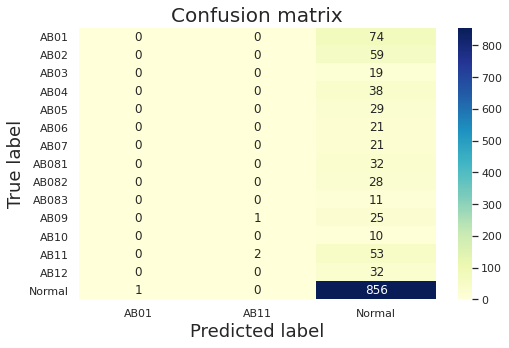

In [15]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [16]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 65.47256097560975%
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       857
           1       0.75      0.01      0.01       455

    accuracy                           0.65      1312
   macro avg       0.70      0.50      0.40      1312
weighted avg       0.69      0.65      0.52      1312



856 1 452 3


Text(48.5, 0.5, 'True label')

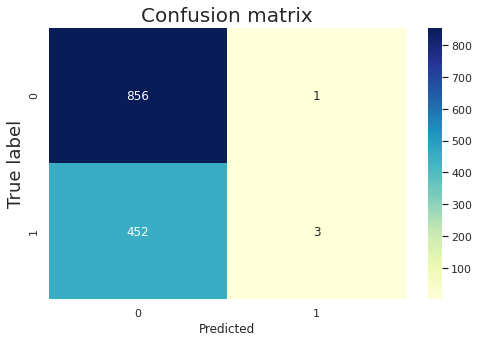

In [17]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [19]:
print(TN, FP, FN, TP)

856 1 452 3


In [17]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB04
classifier accuracy = 0.0% 

###### AB05
classifier accuracy = 0.0% 

###### AB01
classifier accuracy = 0.0% 

###### AB081
classifier accuracy = 0.0% 

###### AB083
classifier accuracy = 0.0% 

###### AB07
classifier accuracy = 0.0% 

###### AB11
classifier accuracy = 0.03636363636363636% 

###### Normal
classifier accuracy = 0.9988331388564761% 

###### AB082
classifier accuracy = 0.0% 

###### AB02
classifier accuracy = 0.0% 

###### AB12
classifier accuracy = 0.0% 

###### AB03
classifier accuracy = 0.0% 

###### AB06
classifier accuracy = 0.0% 

###### AB10
classifier accuracy = 0.0% 

###### AB09
classifier accuracy = 0.0% 



-----------

-------

In [16]:
testdf = pd.read_csv("/home/yupaporn/codes/USAI/Testdf.csv")
print(testdf.shape)
testdf.head()

(1312, 22)


,Unnamed: 0,Unnamed: 0.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,...,originalImage,left,top,width,height,Rleft,Rtop,Rwidth,Rheight,filename
0,111,111,40,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,86.0,133.0,477.0,311.0,0.092664,0.148873,0.513514,0.346614,AB01 P1 C040.JPG
1,112,112,40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,163.0,139.0,532.0,385.0,0.171698,0.154849,0.560377,0.428287,AB01 P2 C040.JPG
2,113,113,40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,https://irisprodseatraining.blob.core.windows....,127.0,135.0,605.0,640.0,0.140316,0.150865,0.667984,0.711155,AB01 P4-1 C040.JPG
3,114,114,40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,...,https://irisprodseatraining.blob.core.windows....,59.0,96.0,643.0,587.0,0.063462,0.107041,0.690385,0.653386,AB01 P5-1 C040.JPG
4,115,115,40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,https://irisprodseatraining.blob.core.windows....,199.0,132.0,618.0,562.0,0.216374,0.146881,0.672515,0.625498,AB01 P3-1 C040.JPG


In [17]:
count_AB = testdf.groupby('Sub_class').size().reset_index(name='count')
print(count_AB)

   Sub_class  count
0       AB01     74
1       AB02     60
2       AB03     18
3       AB04     43
4       AB05     29
5       AB06     21
6       AB07     21
7      AB081     32
8      AB082     28
9      AB083     11
10      AB09     26
11      AB10     10
12      AB11     23
13      AB12     59
14    Normal    857


In [22]:
import pandas as pd
# validation
base_dir  = '/media/tohn/SSD/Images/Image1/'#แก้
dataframe = pd.read_csv( '/home/yupaporn/codes/USAI/Validationdf_fold1_3.csv')#แก้
validation_dir = os.path.join(base_dir, 'validation')

# Train
train_df = pd.read_csv( '/home/yupaporn/codes/USAI/Traindf_fold1_3.csv')#แก้
base_dir0 = '/media/tohn/SSD/Images/Image1/'#แก้
os.chdir(base_dir0)
train_dir = os.path.join(base_dir0, 'train')

In [23]:
dataframe

,Unnamed: 0,Unnamed: 0.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,...,originalImage,left,top,width,height,Rleft,Rtop,Rwidth,Rheight,filename
0,0,1,15,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,141.0,96.0,586.0,614.0,0.143898,0.107041,0.595628,0.683267,AB01 P1 C015.JPG
1,1,11,15,P1,P1,Abnormal,AB02,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,257.0,103.0,538.0,634.0,0.256617,0.115278,0.537205,0.705051,AB02 P1 C015.JPG
2,2,17,15,P1,P1,Abnormal,AB03,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,0.0,184.0,573.0,751.0,0.000862,0.190025,0.638344,0.773737,AB03 P1 C015.JPG
3,3,21,15,P1,P1,Abnormal,AB04,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,278.0,87.0,515.0,496.0,0.278395,0.097096,0.515427,0.551515,AB04 P1 C015.JPG
4,4,23,15,P1,P1,Abnormal,AB05,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,249.0,69.0,439.0,385.0,0.254909,0.076894,0.448980,0.428283,AB05 P1 C015.JPG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1027,1027,308,95,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8C095.jpg
1028,1028,655,349,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8.Case 349.JPG
1029,1029,543,288,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/USimages20...,/media/tohn/HDD/VISION_dataset/USAI/USimages20...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8.Case 288.JPG
1030,1030,380,119,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8C119.jpg


In [24]:
train_df

,Unnamed: 0,Unnamed: 0.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,...,originalImage,left,top,width,height,Rleft,Rtop,Rwidth,Rheight,filename
0,0,1,42,P1,P1,Abnormal,AB02,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,231.0,134.0,544.0,380.0,0.229956,0.149621,0.541516,0.422222,AB02 P1 C042.JPG
1,1,6,42,P1,P1,Abnormal,AB04,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,229.0,98.0,645.0,550.0,0.228564,0.109217,0.643761,0.612121,AB04 P1 C042.JPG
2,2,10,42,P1,P1,Abnormal,AB06,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,267.0,45.0,564.0,525.0,0.263207,0.050631,0.555357,0.583838,AB06 P1 C042.JPG
3,3,20,22,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,200.0,141.0,589.0,501.0,0.201802,0.156841,0.592793,0.557769,AB01 P1 C022.JPG
4,4,29,22,P1,P1,Abnormal,AB02,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,https://irisprodseatraining.blob.core.windows....,155.0,67.0,506.0,639.0,0.166464,0.074874,0.543860,0.711111,AB02 P1 C022.JPG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7387,7387,2370,82,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8C082.jpg
7388,7388,3411,209,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8.Case 209.JPG
7389,7389,3112,197,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8C197.jpg
7390,7390,3821,292,P8,P8,Normal,Normal,/media/tohn/HDD/VISION_dataset/USAI/USimages20...,/media/tohn/HDD/VISION_dataset/USAI/USimages20...,FP-E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P8.Case 292.JPG


In [25]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7392 entries, 0 to 7391
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     7392 non-null   int64  
 1   Unnamed: 0.1   7392 non-null   int64  
 2   Case           7392 non-null   int64  
 3   Abs Position   7392 non-null   object 
 4   Sub Position   7392 non-null   object 
 5   Class          7392 non-null   object 
 6   Sub_class      7392 non-null   object 
 7   Path Full      7392 non-null   object 
 8   Path Crop      7392 non-null   object 
 9   Views          7392 non-null   object 
 10  fold           7392 non-null   int64  
 11  tagName        7392 non-null   object 
 12  originalImage  3388 non-null   object 
 13  left           3388 non-null   float64
 14  top            3388 non-null   float64
 15  width          3388 non-null   float64
 16  height         3388 non-null   float64
 17  Rleft          3388 non-null   float64
 18  Rtop    